In [1]:
import pandas
import matplotlib.pyplot as plt

def flwr_accuracy(folder, key, title, exclude_ids = {}):
    df = pandas.read_csv(folder + "/flwr.csv")
    df = df[~df["id"].isin(exclude_ids)]
    plt.figure(figsize=(8,4))
    for id_val, g in df.groupby("id", sort=False):
        g = g.sort_values("round")
        plt.plot(g["round"], g[key], marker="o", label=str(id_val))

    plt.xlabel("round")
    plt.ylabel(key)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

### MobileNetV3, fixed
noise-multiplier: 1.1, max-grad-norm: 1.0, learning-rate: 0.01, batch-size: 32

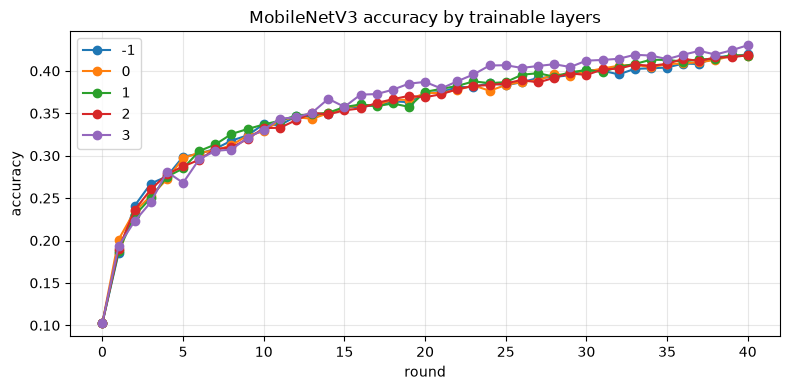

In [2]:
flwr_accuracy("mnv3_freeze_40", "accuracy", "MobileNetV3 accuracy by trainable layers")

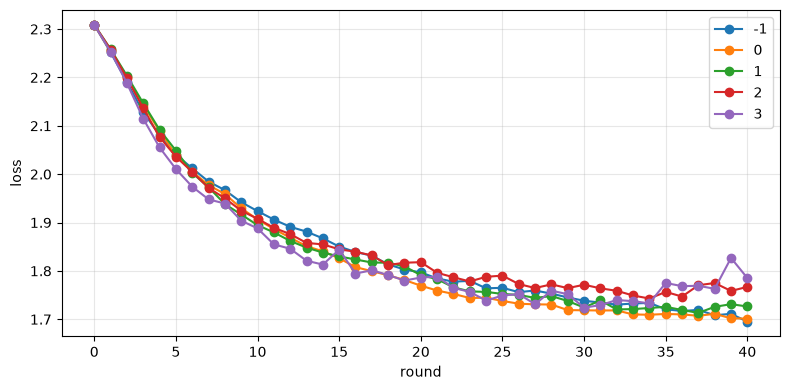

In [3]:
flwr_accuracy("mnv3_freeze_40", "loss", "")

In [4]:
import opacus.accountants
import matplotlib.pyplot as plt

noise_multiplier_1 = 1.1
noise_multiplier_2 = 1.1
noise_multiplier_switch = 90
rounds = 100
delta = 1e-5
n_samples = 50000
batch_size = 32

def epsilon_curve(accountant):
    n_batches = (n_samples + batch_size - 1) // batch_size
    sample_rate = 1 / n_batches
    epsilons = [0]
    for round_idx in range(rounds):
        noise_multiplier = noise_multiplier_1 if round_idx < noise_multiplier_switch else noise_multiplier_2
        for _ in range(n_batches):
            accountant.step(noise_multiplier=noise_multiplier, sample_rate=sample_rate)
        epsilons.append(float(accountant.get_epsilon(delta=delta)))
    return epsilons

def plot_epsilon(data):
    plt.figure(figsize=(12,4))
    for name, arr in data.items():
        plt.plot(arr, label=name)
    plt.xlabel("round")
    plt.ylabel("epsilon")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

(1.095115401999116, 1.0190090872234592)


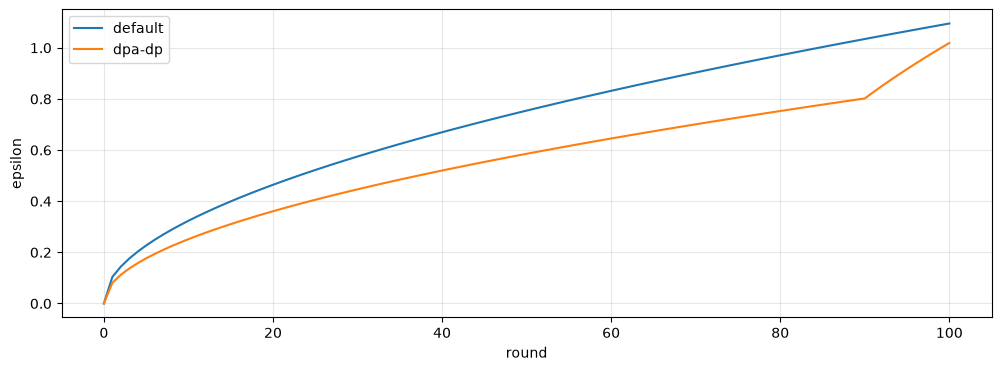

In [5]:
epsilon_data = {}
noise_multiplier_1 = 1.1
noise_multiplier_2 = 1.1
epsilon_data["default"] = epsilon_curve(opacus.accountants.PRVAccountant())
noise_multiplier_1 = 1.3
noise_multiplier_2 = 0.8
epsilon_data["dpa-dp"] = epsilon_curve(opacus.accountants.PRVAccountant())
print(str((epsilon_data["default"][-1], epsilon_data["dpa-dp"][-1])))
plot_epsilon(epsilon_data)